In [3]:
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu")

connection.authenticate_oidc()

print("Zaidan terhubung!")

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=DTLO-AOOY 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.
Zaidan terhubung!


Data CSV berhasil disimpan!


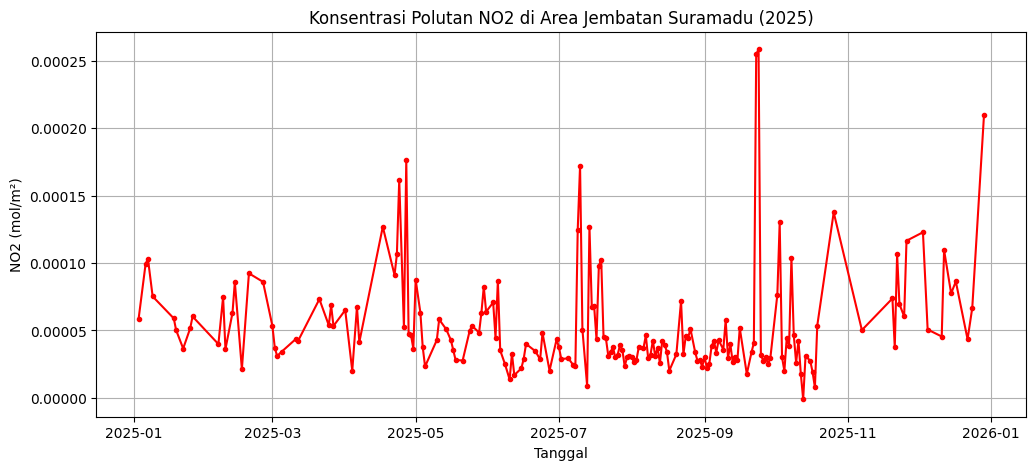

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

area_bbox = {
    "west": 112.65,
    "south": -7.22,
    "east": 112.78,
    "north": -7.14
}

area_polygon = {
    "type": "Polygon",
    "coordinates": [[
        [112.65, -7.22], # Kiri Bawah
        [112.78, -7.22], # Kanan Bawah
        [112.78, -7.14], # Kanan Atas
        [112.65, -7.14], # Kiri Atas
        [112.65, -7.22]  # Kembali ke Kiri Bawah (wajib tertutup)
    ]]
}

datacube = connection.load_collection(
    "SENTINEL_5P_L2",
    spatial_extent=area_bbox,
    temporal_extent=["2025-01-01", "2025-12-31"],
    bands=["NO2"]
)

timeseries = datacube.aggregate_spatial(
    geometries=area_polygon,
    reducer="mean"
)

raw_data = timeseries.execute()

if isinstance(raw_data, dict) and len(raw_data) > 0:
    rows = []
    for date, val in raw_data.items():
        if isinstance(val, list) and len(val) > 0:
            v = val[0][0] if isinstance(val[0], list) and len(val[0]) > 0 else val[0]
        else:
            v = val
        rows.append({"Tanggal": date, "NO2": v})
    df = pd.DataFrame(rows)
elif isinstance(raw_data, pd.DataFrame):
    df = raw_data.reset_index()
else:
    df = pd.DataFrame(raw_data)

if not df.empty and len(df.columns) >= 2:
    # Bersihkan data yang kosong (NaN) dari satelit
    df = df.dropna()
    
    df.to_csv("data_polutan_no2.csv", index=False)
    print("Data CSV berhasil disimpan!")
    
    plt.figure(figsize=(12, 5))
    plt.plot(pd.to_datetime(df.iloc[:, 0]), df.iloc[:, 1], color="red", marker="o", markersize=3, linestyle="-")
    plt.title("Konsentrasi Polutan NO2 di Area Jembatan Suramadu (2025)")
    plt.xlabel("Tanggal")
    plt.ylabel("NO2 (mol/m²)")
    plt.grid(True)
    plt.show()
else:
    print("Respon server masih kosong:", raw_data)

--- Info Dataset Awal ---
Total baris data: 185
Jumlah data kosong (NaN): 0

[SUCCESS] Data bersih berhasil disimpan ke 'data_polutan_no2_clean.csv'!


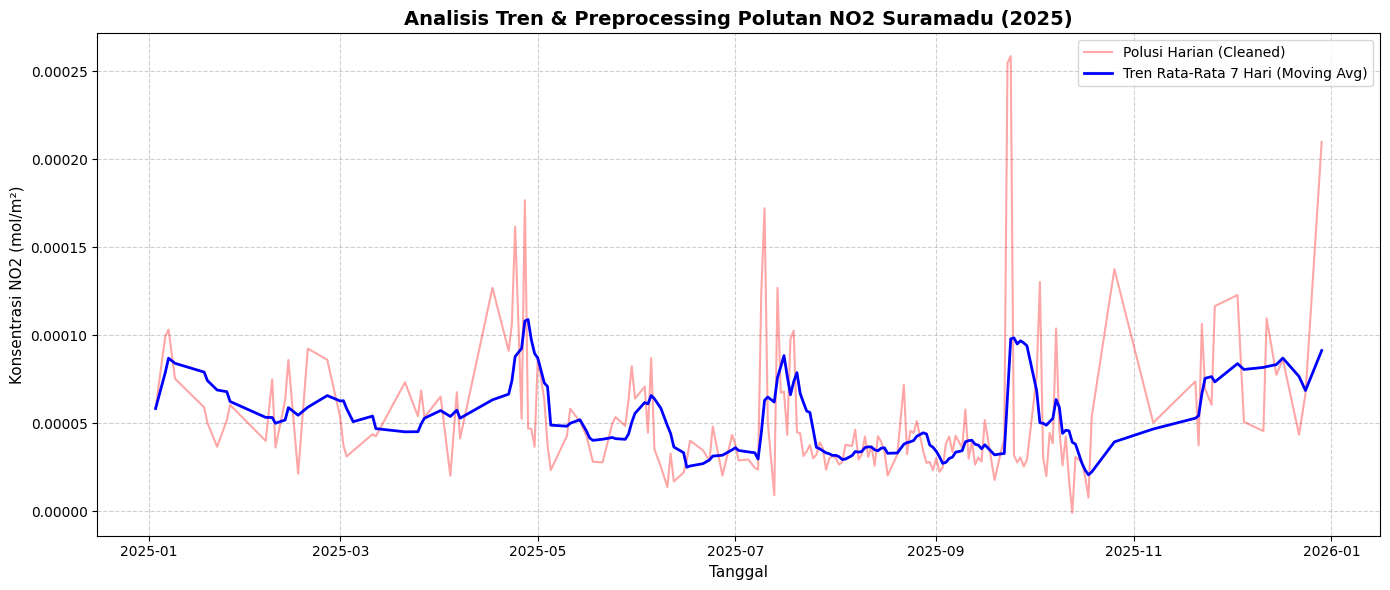


--- Ringkasan Statistik NO2 (mol/m²) ---
Nilai Tertinggi (Peak) : 0.000259
Nilai Rata-rata        : 0.000053
Nilai Terendah         : -0.000001


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data_polutan_no2.csv")

df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df = df.sort_values('Tanggal').reset_index(drop=True)

print("--- Info Dataset Awal ---")
print(f"Total baris data: {len(df)}")
print(f"Jumlah data kosong (NaN): {df['NO2'].isnull().sum()}")

df['NO2_Clean'] = df['NO2'].interpolate(method='linear')

df['NO2_Moving_Avg'] = df['NO2_Clean'].rolling(window=7, min_periods=1).mean()

df.to_csv("data_polutan_no2_clean.csv", index=False)
print("\n[SUCCESS] Data bersih berhasil disimpan ke 'data_polutan_no2_clean.csv'!")

plt.figure(figsize=(14, 6))

plt.plot(df['Tanggal'], df['NO2_Clean'], color='red', alpha=0.35, label='Polusi Harian (Cleaned)')

plt.plot(df['Tanggal'], df['NO2_Moving_Avg'], color='blue', linewidth=2, label='Tren Rata-Rata 7 Hari (Moving Avg)')

plt.title("Analisis Tren & Preprocessing Polutan NO2 Suramadu (2025)", fontsize=14, fontweight='bold')
plt.xlabel("Tanggal", fontsize=11)
plt.ylabel("Konsentrasi NO2 (mol/m²)", fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n--- Ringkasan Statistik NO2 (mol/m²) ---")
print(f"Nilai Tertinggi (Peak) : {df['NO2_Clean'].max():.6f}")
print(f"Nilai Rata-rata        : {df['NO2_Clean'].mean():.6f}")
print(f"Nilai Terendah         : {df['NO2_Clean'].min():.6f}")